# Comparativa Automatizada: Algoritmos Clásicos vs Bioinspirados en MTS
Este notebook ejecuta las mismas pruebas del archivo `mis_pruebas.py`, evaluando 16 variaciones de algoritmos y graficando los resultados.

In [1]:
import json
import os
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Importar tqdm estándar para evitar dependencias de ipywidgets
try:
    from tqdm import tqdm
except ImportError:
    # Fallback por si tqdm no está instalado
    def tqdm(iterable, desc=None):
        if desc: print(f"{desc}...")
        return iterable

## 1. Configuración Base de la Misión
Aquí definimos el diccionario con los parámetros por defecto de los algoritmos y el mapa. Es el esqueleto de nuestros archivos JSON de configuración.

In [2]:
BASE = {
    "version": "1.1",
    "size": [30, 30],
    "cov": [[2, 0], [0, 2]],
    "indicios": [[15, 15]],
    "pesos": [1.0],
    "obj_pos": [None],
    "p_transicion": [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
    "indicio": -1,
    "semilla": 42,
    "num_agents": 1,
    "height": 10,
    "init_pos": [[5, 5]],
    "mov_delta": 1,
    "posible_moves": "8 dir",
    "min_dist": 3,
    "lambda": 0.5,
    "pdmax": 0.8,
    "dmax": 2.1,
    "sigma": 0.7,
    "num_steps": 300,
    "itersteps": 50,
    "separation": 2,
    "plan": False,
    "optimization": "min",
    "show_evolution": False,
    # Parámetros bioinspirados
    "n_ants": 10,
    "n_iterations_aco": 5,
    "alpha": 1.0,
    "beta": 3.0,
    "rho": 0.1,
    "local_rho": 0.05,
    "Q": 1.0,
    "n_iterations_abc": 5,
    "limit": 5,
    "n_onlookers": 3,
    "n_employed": 3,
    "n_iterations_bha": 5,
    "n_stars": 5,
}

## 2. Definición de Experimentos a Lanzar
Creamos dinámicamente cada iteración variando los algoritmos (`ACO`, `ABC`, `BHA` y los `clásicos`) para todas las funciones objetivo (`ET`, `DTR`, `MS`, `ME`).

In [3]:
EXPERIMENTOS = []

# Algoritmos bioinspirados x 4 funciones objetivo
for alg in ["ACO", "ABC", "BHA"]:
    for fo in ["ET", "DTR", "MS", "ME"]:
        EXPERIMENTOS.append((f"{alg}+{fo}", alg, fo))

# Algoritmos clásicos (sin función objetivo bioinspirada)
for alg in ["lawnmower", "expanding_sq", "voraz-heur", "voraz-myope"]:
    EXPERIMENTOS.append((alg, alg, None))

print(f"Total de simulaciones programadas: {len(EXPERIMENTOS)}")

Total de simulaciones programadas: 16


## 3. Ejecución Principal
**Cuidado:** Esta celda puede tardar un par de minutos en resolverse, ya que lanzará el script principal y extraerá los CSV en caliente usando el intérprete de Python del Jupyter Kernel.

In [4]:
os.makedirs("pruebas_test", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

resultados = []
python_exe = sys.executable  # Usa el Python vinculado a este Kernel (tfm_mts)

# Ejecutar experimentos
for experiment in tqdm(EXPERIMENTOS, desc="Progreso Simulaciones"):
    nombre, alg, fo = experiment
    
    # Crear JSON específico
    config = BASE.copy()
    config["algoritmo_busqueda"] = alg
    config["funcion_objetivo"] = fo
    
    json_path = f"pruebas_test/{nombre.replace('+', '_')}.json"
    with open(json_path, "w") as f:
        json.dump(config, f, indent=4)
        
    # Arrancar ejecución del framework principal
    try:
        proc = subprocess.run(
            [python_exe, "bf-busqueda.py", json_path],
            capture_output=True,
            text=True,
            timeout=180
        )
        exito = "OK" in proc.stdout
    except subprocess.TimeoutExpired:
        exito = False
        
    # Extraer los datos CSV generados
    csv_dir = f"resultados/{nombre.replace('+', '_')}"
    if os.path.isdir(csv_dir):
        csvs = [f for f in os.listdir(csv_dir) if f.endswith(".csv")]
    else:
        csvs = []
        
    if not csvs or not exito:
        resultados.append({"nombre": nombre, "pasos": None, "distancia": None, "encontrado": False})
        continue
        
    df = pd.read_csv(os.path.join(csv_dir, csvs[0]), index_col=0)
    
    pasos = float(df.loc["Steps taken", "Agent 0"]) if "Steps taken" in df.index else None
    distancia = float(df.loc["Distance", "Agent 0"]) if "Distance" in df.index else None
    
    # Extraer de forma segura el valor booleano 'encontrado'
    encontrado = False
    if "Found Target" in df.index:
        val = str(df.loc["Found Target", "Agent 0"]).strip().lower()
        encontrado = (val == "true" or val == "1")
        
    resultados.append({
        "nombre": nombre,
        "pasos": pasos,
        "distancia": distancia,
        "encontrado": encontrado
    })

print("¡Simulaciones finalizadas exitosamente!")
pd.DataFrame(resultados).head() # Previsualizamos los primeros 5 resultados

Progreso Simulaciones: 100%|██████████| 16/16 [00:35<00:00,  2.20s/it]

¡Simulaciones finalizadas exitosamente!


,nombre,pasos,distancia,encontrado
0,ACO+ET,21.0,27.2132,True
1,ACO+DTR,25.0,32.4558,True
2,ACO+MS,20.0,24.1421,True
3,ACO+ME,26.0,33.4558,True
4,ABC+ET,24.0,28.5563,True


## 4. Visualización de los Resultados
Generamos directamente el gráfico separando por Pasos vs Distancia Recorrida.

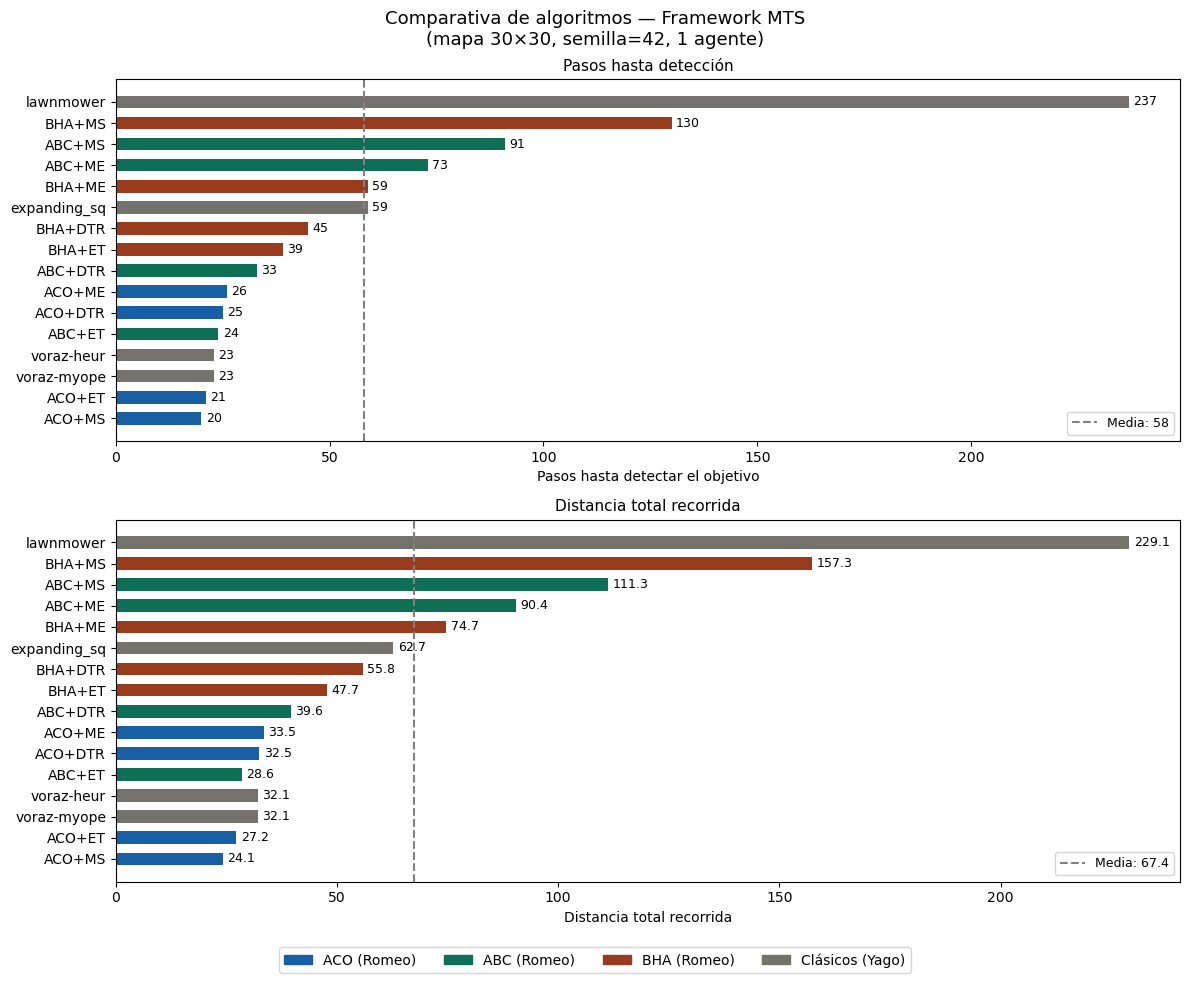

In [5]:
df_res = pd.DataFrame(resultados).dropna(subset=["pasos"])
df_res = df_res.sort_values("pasos")

colores_map = {
    "ACO": "#185FA5", "ABC": "#0F6E56", "BHA": "#993C1D",
    "lawnmower": "#73726c", "expanding_sq": "#73726c",
    "voraz-heur": "#73726c", "voraz-myope": "#73726c"
}

def color_de(nombre):
    for key in colores_map:
        if nombre.startswith(key): return colores_map[key]
    return "#888"

colores = [color_de(n) for n in df_res["nombre"]]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle("Comparativa de algoritmos — Framework MTS\n(mapa 30×30, semilla=42, 1 agente)", fontsize=13)

# GRÁFICA 1: Pasos
ax1 = axes[0]
bars1 = ax1.barh(df_res["nombre"], df_res["pasos"], color=colores, height=0.6)
ax1.set_xlabel("Pasos hasta detectar el objetivo")
ax1.set_title("Pasos hasta detección", fontsize=11)
ax1.axvline(df_res["pasos"].mean(), color="gray", linestyle="--", label=f'Media: {df_res["pasos"].mean():.0f}')
ax1.legend(fontsize=9)
for bar, val in zip(bars1, df_res["pasos"]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{int(val)}", va="center", fontsize=9)

# GRÁFICA 2: Distancia
ax2 = axes[1]
bars2 = ax2.barh(df_res["nombre"], df_res["distancia"], color=colores, height=0.6)
ax2.set_xlabel("Distancia total recorrida")
ax2.set_title("Distancia total recorrida", fontsize=11)
ax2.axvline(df_res["distancia"].mean(), color="gray", linestyle="--", label=f'Media: {df_res["distancia"].mean():.1f}')
ax2.legend(fontsize=9)
for bar, val in zip(bars2, df_res["distancia"]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{val:.1f}", va="center", fontsize=9)

# Leyenda global
leyenda = [
    mpatches.Patch(color="#185FA5", label="ACO (Romeo)"),
    mpatches.Patch(color="#0F6E56", label="ABC (Romeo)"),
    mpatches.Patch(color="#993C1D", label="BHA (Romeo)"),
    mpatches.Patch(color="#73726c", label="Clásicos (Yago)")
]
fig.legend(handles=leyenda, loc="lower center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])

# Mostramos el gráfico final directamente en la celda
plt.show()